Connect to dataset on google drive if you want to run notebook on google colab

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import all required libraries and constants
import dlib
import cv2
import os
import re
import json
from pylab import *
from PIL import Image, ImageChops, ImageEnhance
import scipy
import scipy.misc
from scipy import ndimage
import skimage.io
import skimage.filters
import sys
import tensorflow as tf
import cv2
import os
import numpy as np
from PIL import Image, ImageChops, ImageEnhance
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import seaborn as sns

We here evaluate our DenseNet-based model on the test-set

In [ ]:
visual_model = load_model('/content/drive/MyDrive/epochs_50_layers_best_weights_32_50_aug_densenet_model.h5')

In [ ]:
import seaborn as sns
from PIL import Image
# Function to test a video and return the predicted class
def test_video(video_path,main_path):
    fake_prob = 0
    real_prob = 0
    fake_prob_frames = 0
    real_prob_frames = 0
    i = 0
    while True:
      frame_path = main_path + os.path.basename(video_path).split('.')[0] + '_' + str(i) + '.png'
      if os.path.exists(frame_path):
          # Load the image
          # Load the image using PIL
          img = Image.open(frame_path)

          # Convert the PIL Image to a NumPy array
          img_array = img_to_array(img)

          # Resize the image using OpenCV
          resized_img_array = cv2.resize(img_array, (128, 128))

          # Flatten and normalize data
          data = resized_img_array.flatten() / 255.0
          data = data.reshape(-1, 128, 128, 3)
          # Apply a threshold to convert probabilities into binary predictions
          threshold = 0.5
          y_pred = (visual_model.predict(data) > threshold).astype(int)
          if y_pred==1:
            real_prob_frames+=1
          else:
            fake_prob_frames+=1
          i+=1
      else:
          # frames finished, then break loop
          break
    if fake_prob_frames > real_prob_frames: #thershold
      fake_prob_frames = 0
      real_prob_frames = 0
      return 0
    else:
      fake_prob_frames = 0
      real_prob_frames = 0
      return 1


The dataset comprises four distinct classes represented by folders: RARV, FARV, RAFV, and FAFV.  Initially, we assess the accuracy of each individual class and subsequently calculate the overall accuracy.

Videos in RARV and FARV folders are considered the real videos (positive samples)

Videos in RAFV and FAFV folders are considered the fake videos -> (negative samples)

Thus we will evaluate videos in RARV and FARV together as real videos and videos in RAFV and FAFV as fake videos.

In [ ]:
# counter for videos will be detected fake
video_fakeness = 0
# videos in RARV and FARV folders
total_real_videos= 0
#fake predictions in RARV and FARV videos
total_fake_predictions_in_real_videos = 0
#real predictions in RARV and FARV videos
total_real_predictions_in_real_videos = 0

In [ ]:
# Set the path to the directory you want to loop through
directory_path = '/content/drive/MyDrive/RARV_test_moved'
# List files in the directory
files = os.listdir(directory_path)
video_fakeness = 0
total_real_videos= 0
#fake predictions in RARV and FARV videos
total_fake_predicted_in_real_videos = 0
#real predictions in RARV and FARV videos
total_real_predicted_in_real_videos = 0
# Loop through videos in RARV folder
for video_file in files:
    total_real_videos+=1
    video_name = os.path.splitext(video_file)[0]  # Get the name without the extension
    video_file_path = os.path.join(directory_path, video_file)
    predicted_class = test_video(video_file_path,'/content/drive/MyDrive/frames_RARV_test/')
    print(predicted_class)

    if(predicted_class==0):
      total_fake_predicted_in_real_videos+=1
    else:

    video_fakeness = 0 #reset fakeness counter to zero



1/1 [==============================] - 0s 111ms/step
1
visual video is real
1/1 [==============================] - 0s 124ms/step
0
visual video is fake
1/1 [==============================] - 0s 114ms/step
1
visual video is real
1/1 [==============================] - 0s 121ms/step
1
visual video is real
1/1 [==============================] - 0s 121ms/step
1
visual video is real
1/1 [==============================] - 0s 207ms/step
1
visual video is real
1/1 [==============================] - 0s 180ms/step
0
visual video is fake
1/1 [==============================] - 0s 116ms/step
1
visual video is real
1/1 [==============================] - 0s 109ms/step
1
visual video is real
1/1 [==============================] - 0s 123ms/step
0
visual video is fake
1/1 [==============================] - 0s 118ms/step
1
visual video is real
1/1 [==============================] - 0s 112ms/step
1
visual video is real
1/1 [==============================] - 0s 115ms/step
1
visual video is real
1/1 [=======

In [ ]:
# Set the path to the directory you want to loop through
directory_path = '/content/drive/MyDrive/FARV_test_moved'
# List files in the directory
files = os.listdir(directory_path)
video_fakeness = 0
# Loop through videos in FARV
for video_file in files:
    total_real_videos+=1
    video_name = os.path.splitext(video_file)[0]  # Get the name without the extension
    video_file_path = os.path.join(directory_path, video_file)
    predicted_class = test_video(video_file_path,'/content/drive/MyDrive/frames_FARV_test/')
    print(predicted_class)
    if(predicted_class==0):
      print("visual video is fake")
      total_fake_predicted_in_real_videos+=1
    else:
      print("visual video is real")

    video_fakeness=0 #reset fakeness counter to zero

1/1 [==============================] - 0s 180ms/step
1
visual video is real
1/1 [==============================] - 0s 129ms/step
1
visual video is real
1/1 [==============================] - 0s 131ms/step
1
visual video is real
1/1 [==============================] - 0s 107ms/step
1
visual video is real
1/1 [==============================] - 0s 109ms/step
1
visual video is real
1/1 [==============================] - 0s 109ms/step
1
visual video is real
1/1 [==============================] - 0s 110ms/step
1
visual video is real
1/1 [==============================] - 0s 108ms/step
0
visual video is fake
1/1 [==============================] - 0s 105ms/step
1
visual video is real
1/1 [==============================] - 0s 109ms/step
1
visual video is real
1/1 [==============================] - 0s 111ms/step
1
visual video is real
1
visual video is real
1/1 [==============================] - 0s 109ms/step
0
visual video is fake
1/1 [==============================] - 0s 187ms/step
1
visual vid

In [ ]:
total_real_predicted_in_real_videos = total_real_videos - total_fake_predicted_in_real_videos

In [ ]:
# counter for videos will be detected fake
video_fakeness = 0
# videos in FAFV and RAFV folders
total_fake_videos= 0
#fake predictions in FAFV and RAFV folders
total_fake_predictions_in_fake_videos = 0
#fake predictions in FAFV and RAFV folders
total_real_predictions_in_fake_videos = 0

In [ ]:
# Set the path to the directory you want to loop through
directory_path = '/content/drive/MyDrive/FAFV_test_moved'
audio_directory_path = '/content/drive/MyDrive/FAFV_audio_test'
# List files in the directory
files = os.listdir(directory_path)
# Loop through the files
for video_file in files:
    total_fake_videos+=1
    video_name = os.path.splitext(video_file)[0]  # Get the name without the extension
    video_file_path = os.path.join(directory_path, video_file)
    predicted_class = test_video(video_file_path,'/content/drive/MyDrive/frames_FAFV_test/')
    print(predicted_class)
    if predicted_class == 0:
        print("visual video is fake")
        total_fake_predicted_in_fake_videos += 1
    else:
        print("visual video is real")

    video_fakeness=0 #reset fakeness counter to zero


Streaming output truncated to the last 5000 lines.
0
visual video is fake
1/1 [==============================] - 0s 190ms/step
0
visual video is fake
1/1 [==============================] - 0s 105ms/step
0
visual video is fake
1/1 [==============================] - 0s 123ms/step
0
visual video is fake
1/1 [==============================] - 0s 114ms/step
0
visual video is fake
1/1 [==============================] - 0s 119ms/step
0
visual video is fake
1/1 [==============================] - 0s 131ms/step
0
visual video is fake
1/1 [==============================] - 0s 118ms/step
0
visual video is fake
1/1 [==============================] - 0s 107ms/step
0
visual video is fake
1/1 [==============================] - 0s 110ms/step
0
visual video is fake
1/1 [==============================] - 0s 115ms/step
0
visual video is fake
1/1 [==============================] - 0s 120ms/step
0
visual video is fake
1/1 [==============================] - 0s 111ms/step
0
visual video is fake
1/1 [=========

In [ ]:
import os
# Set the path to the directory you want to loop through
directory_path = '/content/drive/MyDrive/RAFV_test_moved'
audio_directory_path = '/content/drive/MyDrive/RAFV_audio_test'
# List files in the directory
files = os.listdir(directory_path)
# Loop through the files
for video_file in files:
    total_fake_videos+=1
    video_name = os.path.splitext(video_file)[0]  # Get the name without the extension
    video_file_path = os.path.join(directory_path, video_file)
    predicted_class = test_video(video_file_path,'/content/drive/MyDrive/frames_RAFV_test/')
    print(predicted_class)
    if predicted_class == 0:
        print("visual video is fake")
        total_fake_predicted_in_fake_videos += 1
    else:
        print("visual video is real")

    video_fakeness = 0 #reset fakeness counter to zero


Streaming output truncated to the last 5000 lines.
0
visual video is fake
1/1 [==============================] - 0s 184ms/step
0
visual video is fake
1/1 [==============================] - 0s 111ms/step
0
visual video is fake
1/1 [==============================] - 0s 120ms/step
0
visual video is fake
1/1 [==============================] - 0s 111ms/step
0
visual video is fake
1/1 [==============================] - 0s 122ms/step
0
visual video is fake
1/1 [==============================] - 0s 132ms/step
0
visual video is fake
1/1 [==============================] - 0s 119ms/step
0
visual video is fake
1/1 [==============================] - 0s 143ms/step
0
visual video is fake
1/1 [==============================] - 0s 187ms/step
0
visual video is fake
1/1 [==============================] - 0s 206ms/step
0
visual video is fake
1/1 [==============================] - 0s 128ms/step
0
visual video is fake
1/1 [==============================] - 0s 129ms/step
0
visual video is fake
1/1 [=========

In [ ]:
total_real_predicted_in_fake_videos = total_fake_videos - total_fake_predicted_in_fake_videos

total accuracy = (true positive + true negative) / (total poistive + total negative) then,

true positive is total_real_predicted_in_real_videos

true negative is total_fake_predicted_in_fake_videos

total positive is total_real_videos

total negative is total_fake_videos


In [ ]:
total_accuracy = (total_real_predicted_in_real_videos+total_fake_predicted_in_fake_videos) / (total_real_videos+total_fake_videos)
print(total_accuracy)

0.935152787497


Now we decalre y_test (ground truth) and y_pred

y_test is array of total real videos and total fake videos,

y_pred is array of real and fake predictions to the corresponding videos in y_test

In [ ]:
y_test = np.concatenate([np.ones(total_real_videos), np.zeros(total_fake_videos)])

predictions_in_real_videos = np.concatenate([np.ones(total_real_predicted_in_real_videos), np.zeros(total_fake_predicted_in_real_videos)])
predictions_in_fake_videos = np.concatenate([np.ones((total_real_predicted_in_fake_videos)), np.zeros(total_fake_predicted_in_fake_videos)])

# Merge the arrays
y_pred = np.concatenate([predictions_in_real_videos, predictions_in_fake_videos])

print(y_test)
print(y_pred)

[1. 1. 1. ... 0. 0. 0.]
[1. 1. 1. ... 0. 0. 0.]


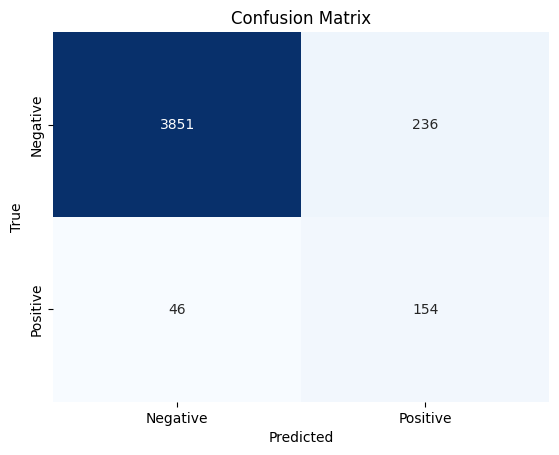

In [ ]:
from sklearn.metrics import confusion_matrix
# Create the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

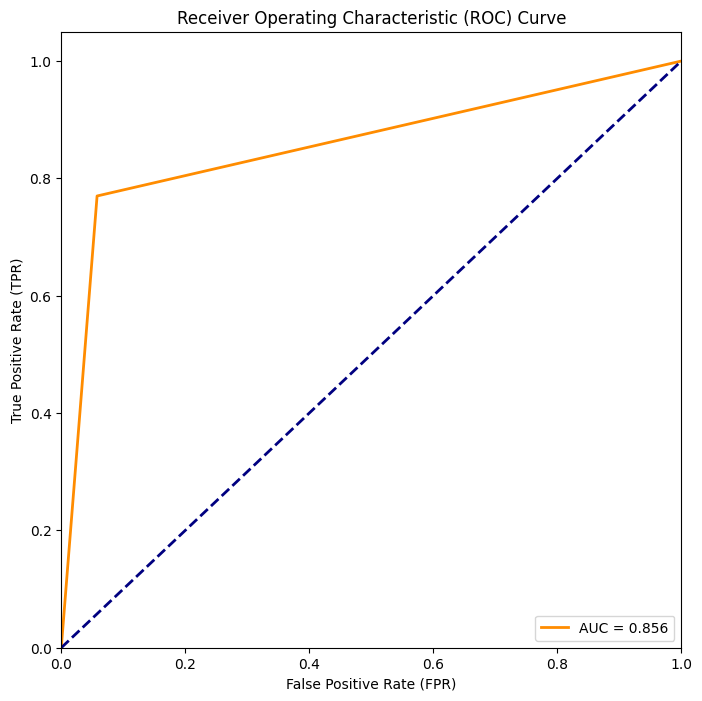

In [ ]:
from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Compute area under the curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()